In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import warnings, json, os, textwrap, itertools
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print("Libraries loaded ✓")


Libraries loaded ✓


In [20]:

df = pd.read_csv(r'C:\Users\asus\Downloads\healthvector\patient_health_data.csv', parse_dates=['date_of_test'])
print("Shape:", df.shape)
df.head(3)


Shape: (36517, 12)


,patient_id,date_of_test,param_name,parameter_group,result,unit,low_range,high_range,parameter_label,gender,visits,age_band
0,P0001,2023-03-11,creatinine,renal,0.95,mg/dL,0.6,1.2,Creatinine,Male,3,35-39
1,P0001,2023-03-11,fasting_glucose,glucose,145.40,mg/dL,70.0,109.0,Fasting Glucose,Male,3,35-39
2,P0001,2023-03-11,hdl,lipid,39.60,mg/dL,40.0,60.0,HDL,Male,3,35-39


In [3]:

print("=== Data Quality ===")
print("Missing values per column:")
print(df.isnull().sum())
print("\nDate range:", df['date_of_test'].min().date(), "to", df['date_of_test'].max().date())
print("Unique patients:", df['patient_id'].nunique())
print("Parameters:", df['param_name'].nunique())


=== Data Quality ===
Missing values per column:
patient_id         0
date_of_test       0
param_name         0
parameter_group    0
result             0
unit               0
low_range          0
high_range         0
parameter_label    0
gender             0
visits             0
age_band           0
dtype: int64

Date range: 2019-06-29 to 2026-04-19
Unique patients: 1000
Parameters: 11


In [4]:
df.isna().any()

patient_id         False
date_of_test       False
param_name         False
parameter_group    False
result             False
unit               False
low_range          False
high_range         False
parameter_label    False
gender             False
visits             False
age_band           False
dtype: bool

In [5]:

# Coverage per parameter
coverage = df.groupby('param_name')['patient_id'].nunique().reset_index()
coverage.columns = ['param_name','patients_with_data']
coverage['coverage_pct'] = (coverage['patients_with_data'] / df['patient_id'].nunique() * 100).round(1)
print(coverage.to_string(index=False))


     param_name  patients_with_data  coverage_pct
     creatinine                1000         100.0
fasting_glucose                 994          99.4
          hba1c                 705          70.5
            hdl                 999          99.9
            ldl                 999          99.9
           sgot                 986          98.6
           sgpt                 987          98.7
total_bilirubin                 981          98.1
  total_protein                 972          97.2
  triglycerides                 999          99.9
      uric_acid                 992          99.2


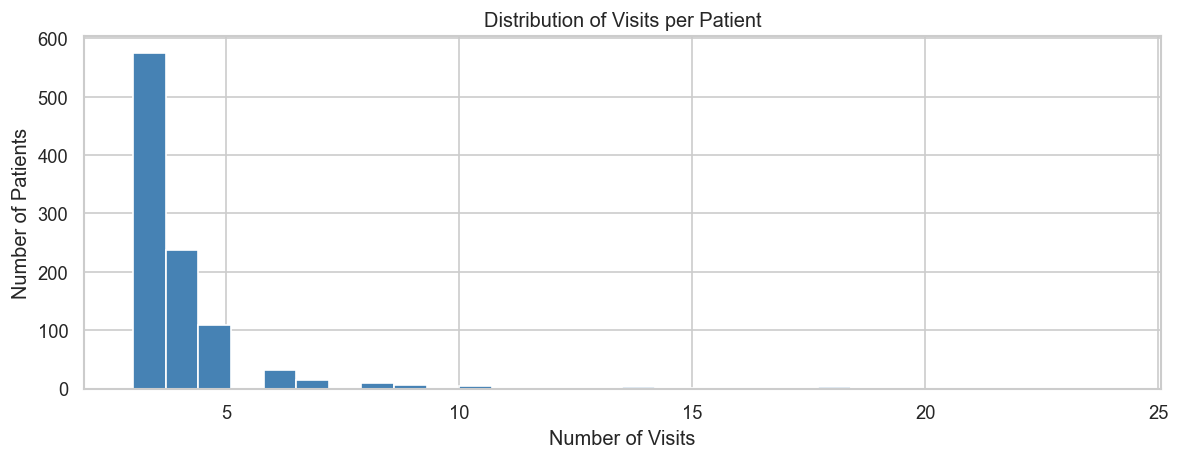

Min visits: 3 | Max: 24 | Median: 3.0


In [6]:
#visits per patient
visits_per_patient = df.groupby('patient_id')['visits'].first()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(visits_per_patient, bins=30, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Visits')
ax.set_ylabel('Number of Patients')
ax.set_title('Distribution of Visits per Patient')
plt.tight_layout()
plt.savefig('fig_visits_distribution.png', bbox_inches='tight')
plt.show()
print("Min visits:", visits_per_patient.min(), "| Max:", visits_per_patient.max(), "| Median:", visits_per_patient.median())

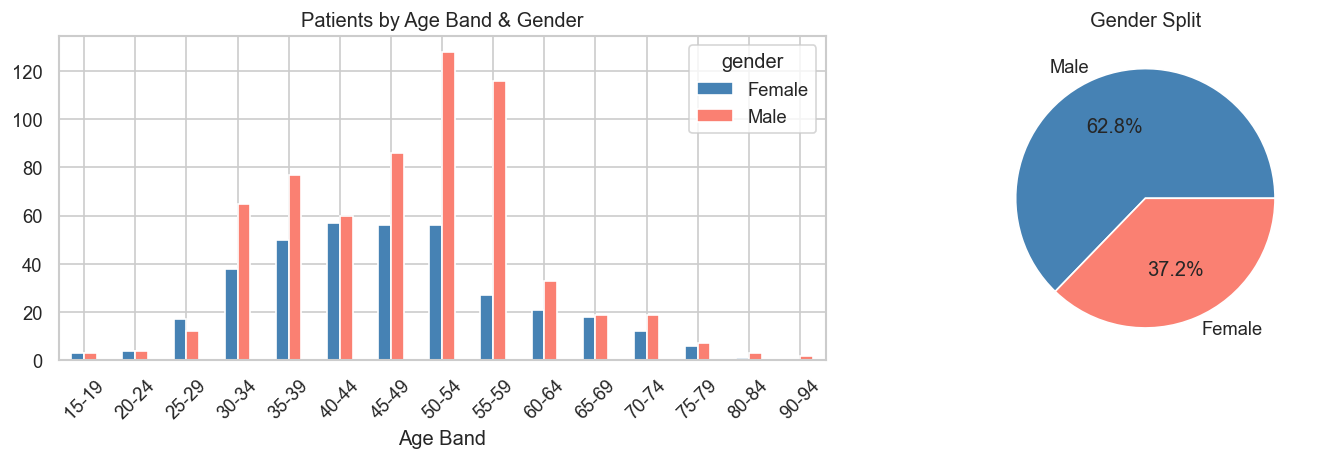

In [7]:

# Age band & gender distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df.drop_duplicates('patient_id')[['age_band','gender']].value_counts().unstack().plot(kind='bar', ax=axes[0], color=['steelblue','salmon'])
axes[0].set_title('Patients by Age Band & Gender')
axes[0].set_xlabel('Age Band')
axes[0].tick_params(axis='x', rotation=45)

df['gender'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['steelblue','salmon'])
axes[1].set_title('Gender Split')
axes[1].set_ylabel('')
plt.tight_layout()
plt.savefig('fig_demographics.png', bbox_inches='tight')
plt.show()


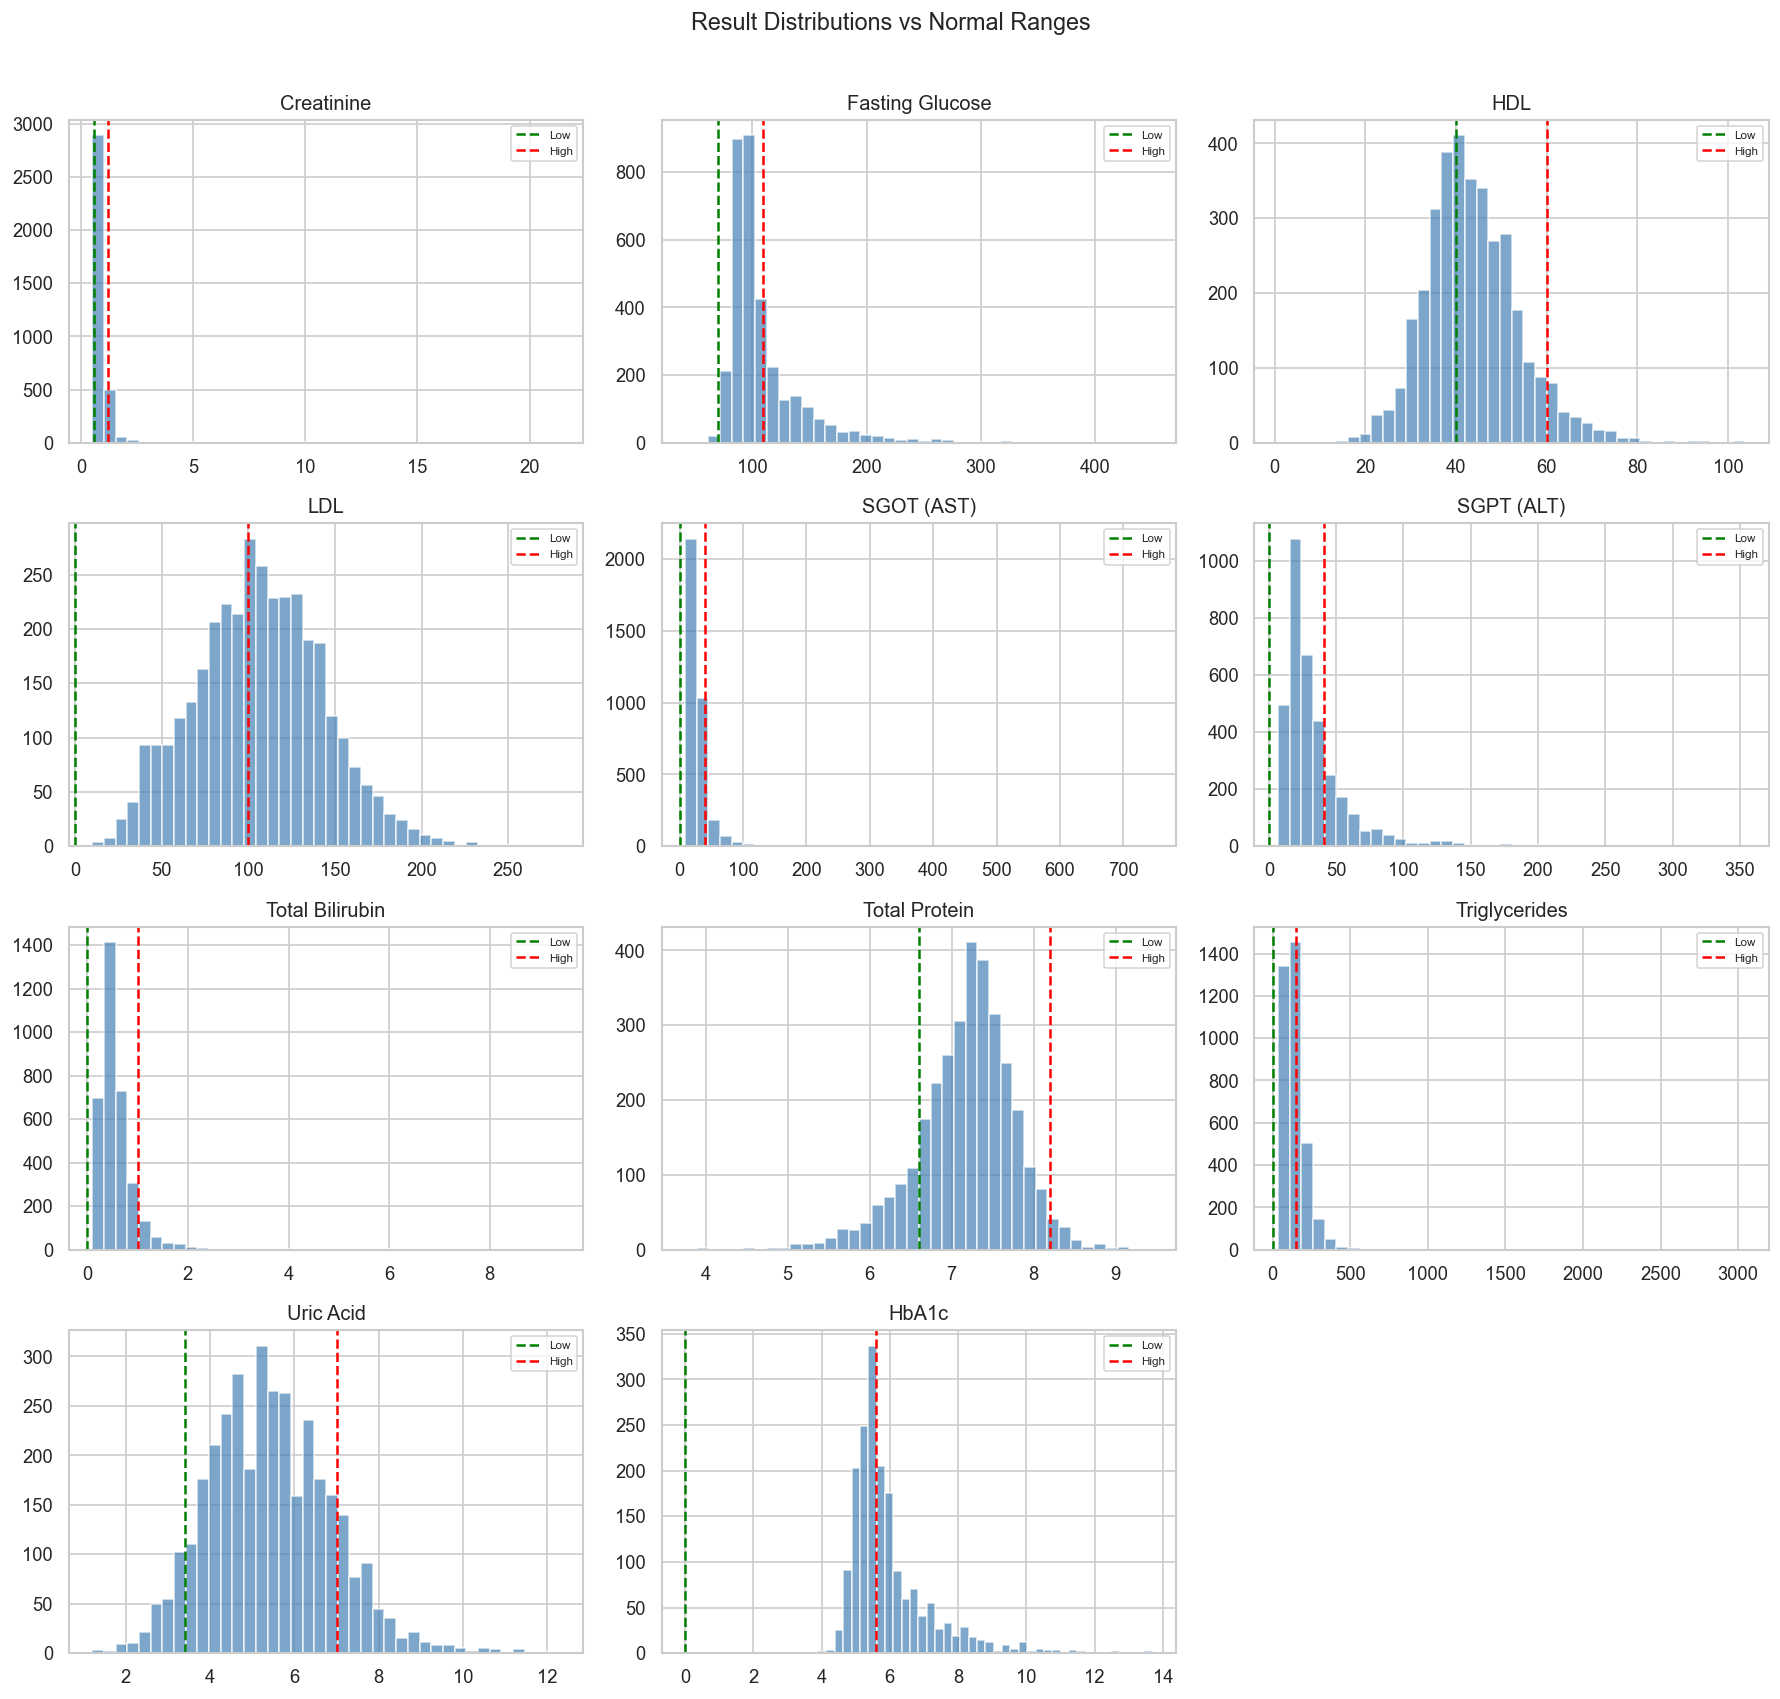

In [8]:

# Result distributions vs normal range per parameter
params = df['param_name'].unique()
fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, param in enumerate(params):
    sub = df[df['param_name'] == param]
    lo = sub['low_range'].iloc[0]
    hi = sub['high_range'].iloc[0]
    label = sub['parameter_label'].iloc[0]
    axes[i].hist(sub['result'].dropna(), bins=40, color='steelblue', alpha=0.7, edgecolor='white')
    axes[i].axvline(lo, color='green', linestyle='--', label='Low')
    axes[i].axvline(hi, color='red', linestyle='--', label='High')
    axes[i].set_title(label)
    axes[i].legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Result Distributions vs Normal Ranges', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig_param_distributions.png', bbox_inches='tight')
plt.show()


In [9]:
# ── Abnormality Logic ─────────────────────────────────────────────────
# hdl and total_protein: only LOW values are the clinical concern
# all other params: outside either boundary is abnormal

low_is_bad_params = {'hdl', 'total_protein'}

def is_abnormal(row):
    if row['param_name'] in low_is_bad_params:
        return row['result'] < row['low_range']
    return (row['result'] < row['low_range']) or (row['result'] > row['high_range'])

df['is_abnormal'] = df.apply(is_abnormal, axis=1)

print("✅ is_abnormal flag added")
print(f"Total abnormal readings : {df['is_abnormal'].sum():,}")
print(f"Total normal readings   : {(~df['is_abnormal']).sum():,}")
df[['patient_id','param_name','result','low_range','high_range','is_abnormal']].head(10)

✅ is_abnormal flag added
Total abnormal readings : 9,837
Total normal readings   : 26,680


,patient_id,param_name,result,low_range,high_range,is_abnormal
0,P0001,creatinine,0.95,0.6,1.2,False
1,P0001,fasting_glucose,145.40,70.0,109.0,True
2,P0001,hdl,39.60,40.0,60.0,True
3,P0001,ldl,65.70,0.0,100.0,False
4,P0001,sgot,19.60,0.0,40.0,False
5,P0001,sgpt,16.70,0.0,41.0,False
6,P0001,total_bilirubin,1.18,0.0,1.0,True
7,P0001,total_protein,7.56,6.6,8.2,False
8,P0001,triglycerides,78.90,0.0,150.0,False
9,P0001,uric_acid,5.20,3.4,7.0,False


In [10]:
from scipy import stats

# ── Slope Computation ─────────────────────────────────────────────────
# x = days since first visit for that patient×param group
# y = lab result value
# Returns slope, r², p_value (None if fewer than 3 visits)

def compute_slope(grp):
    grp = grp.sort_values('date_of_test')
    x = (grp['date_of_test'] - grp['date_of_test'].min()).dt.days.values
    y = grp['result'].values
    if len(x) >= 3:
        slope, _, r_value, p_value, _ = stats.linregress(x, y)
        return pd.Series({'slope': slope, 'r2': r_value**2, 'p_value': p_value})
    return pd.Series({'slope': None, 'r2': None, 'p_value': None})

slope_df = (
    df.groupby(['patient_id', 'param_name'])
    .apply(compute_slope)
    .reset_index()
)

print("✅ Slope computed per patient × parameter")
print(f"Shape: {slope_df.shape}")
slope_df.head(10)

✅ Slope computed per patient × parameter
Shape: (10614, 5)


,patient_id,param_name,slope,r2,p_value
0,P0001,creatinine,NaN,NaN,NaN
1,P0001,fasting_glucose,NaN,NaN,NaN
2,P0001,hba1c,NaN,NaN,NaN
3,P0001,hdl,NaN,NaN,NaN
4,P0001,ldl,NaN,NaN,NaN
5,P0001,sgot,NaN,NaN,NaN
6,P0001,sgpt,NaN,NaN,NaN
7,P0001,total_bilirubin,NaN,NaN,NaN
8,P0001,total_protein,NaN,NaN,NaN
9,P0001,triglycerides,NaN,NaN,NaN


In [11]:
# ── Recent Direction ──────────────────────────────────────────────────
# Looks at last 3 visits only
# For low_is_bad params (hdl, total_protein): rising = improving
# For all others: falling = improving

def recent_direction(grp):
    grp = grp.sort_values('date_of_test')
    results = grp['result'].values
    param   = grp['param_name'].iloc[0]
    
    if len(results) < 3:
        return 'insufficient_data'
    
    recent = results[-3:]
    low_is_bad = param in low_is_bad_params
    
    if low_is_bad:
        improving = all(recent[i] < recent[i+1] for i in range(len(recent)-1))
        worsening = all(recent[i] > recent[i+1] for i in range(len(recent)-1))
    else:
        improving = all(recent[i] > recent[i+1] for i in range(len(recent)-1))
        worsening = all(recent[i] < recent[i+1] for i in range(len(recent)-1))
    
    if improving: return 'improving'
    if worsening: return 'worsening'
    return 'stable'

recent_dir_df = (
    df.groupby(['patient_id', 'param_name'])
    .apply(recent_direction)
    .reset_index()
)
recent_dir_df.columns = ['patient_id', 'param_name', 'recent_direction']

print("✅ Recent direction computed")
print(recent_dir_df['recent_direction'].value_counts().to_string())
recent_dir_df.head(10)

✅ Recent direction computed
recent_direction
stable               5558
insufficient_data    2041
worsening            1530
improving            1485


,patient_id,param_name,recent_direction
0,P0001,creatinine,insufficient_data
1,P0001,fasting_glucose,insufficient_data
2,P0001,hba1c,insufficient_data
3,P0001,hdl,insufficient_data
4,P0001,ldl,insufficient_data
5,P0001,sgot,insufficient_data
6,P0001,sgpt,insufficient_data
7,P0001,total_bilirubin,insufficient_data
8,P0001,total_protein,insufficient_data
9,P0001,triglycerides,insufficient_data


In [12]:
# ── Abnormality Signals Per Patient × Parameter ───────────────────────

def compute_abnormal_signals(grp):
    grp   = grp.sort_values('date_of_test')
    flags = grp['is_abnormal'].values
    results = grp['result'].values
    n     = len(flags)
    
    transitions = sum(1 for i in range(n-1) if flags[i] != flags[i+1])
    
    return pd.Series({
        'n_visits'               : n,
        'n_abnormal_visits'      : int(flags.sum()),
        'currently_abnormal'     : bool(flags[-1]),
        'ever_abnormal'          : bool(flags.any()),
        'always_abnormal'        : bool(flags.all()),
        'was_normal_early'       : bool(not flags[0]),
        'crossed_into_abnormal'  : any(not flags[i] and flags[i+1] for i in range(n-1)),
        'crossed_into_normal'    : any(flags[i] and not flags[i+1] for i in range(n-1)),
        'transitions'            : transitions,
        'first_val'              : results[0],
        'last_val'               : results[-1],
        'change_first_to_last'   : results[-1] - results[0],
        'total_range'            : results.max() - results.min(),
    })

signals_df = (
    df.groupby(['patient_id', 'param_name'])
    .apply(compute_abnormal_signals)
    .reset_index()
)

print("✅ Abnormality signals computed")
print(f"Shape: {signals_df.shape}")
signals_df.head(10)

✅ Abnormality signals computed
Shape: (10614, 15)


,patient_id,param_name,n_visits,n_abnormal_visits,currently_abnormal,ever_abnormal,always_abnormal,was_normal_early,crossed_into_abnormal,crossed_into_normal,transitions,first_val,last_val,change_first_to_last,total_range
0,P0001,creatinine,2,0,False,False,False,True,False,False,0,0.95,0.90,-0.05,0.05
1,P0001,fasting_glucose,2,1,False,True,False,False,False,True,1,145.40,96.60,-48.80,48.80
2,P0001,hba1c,1,0,False,False,False,True,False,False,0,5.30,5.30,0.00,0.00
3,P0001,hdl,2,2,True,True,True,False,False,False,0,39.60,39.50,-0.10,0.10
4,P0001,ldl,2,0,False,False,False,True,False,False,0,65.70,85.70,20.00,20.00
5,P0001,sgot,2,0,False,False,False,True,False,False,0,19.60,22.80,3.20,3.20
6,P0001,sgpt,2,0,False,False,False,True,False,False,0,16.70,21.70,5.00,5.00
7,P0001,total_bilirubin,2,1,False,True,False,False,False,True,1,1.18,0.84,-0.34,0.34
8,P0001,total_protein,2,0,False,False,False,True,False,False,0,7.56,7.99,0.43,0.43
9,P0001,triglycerides,2,0,False,False,False,True,False,False,0,78.90,90.20,11.30,11.30


In [13]:
# ── Merge slope + recent direction + abnormality signals ──────────────

master_signals = (
    signals_df
    .merge(slope_df,      on=['patient_id','param_name'], how='left')
    .merge(recent_dir_df, on=['patient_id','param_name'], how='left')
)

print("✅ Master signals table ready")
print(f"Shape: {master_signals.shape}")
master_signals.head(10)

✅ Master signals table ready
Shape: (10614, 19)


,patient_id,param_name,n_visits,n_abnormal_visits,currently_abnormal,ever_abnormal,always_abnormal,was_normal_early,crossed_into_abnormal,crossed_into_normal,transitions,first_val,last_val,change_first_to_last,total_range,slope,r2,p_value,recent_direction
0,P0001,creatinine,2,0,False,False,False,True,False,False,0,0.95,0.90,-0.05,0.05,NaN,NaN,NaN,insufficient_data
1,P0001,fasting_glucose,2,1,False,True,False,False,False,True,1,145.40,96.60,-48.80,48.80,NaN,NaN,NaN,insufficient_data
2,P0001,hba1c,1,0,False,False,False,True,False,False,0,5.30,5.30,0.00,0.00,NaN,NaN,NaN,insufficient_data
3,P0001,hdl,2,2,True,True,True,False,False,False,0,39.60,39.50,-0.10,0.10,NaN,NaN,NaN,insufficient_data
4,P0001,ldl,2,0,False,False,False,True,False,False,0,65.70,85.70,20.00,20.00,NaN,NaN,NaN,insufficient_data
5,P0001,sgot,2,0,False,False,False,True,False,False,0,19.60,22.80,3.20,3.20,NaN,NaN,NaN,insufficient_data
6,P0001,sgpt,2,0,False,False,False,True,False,False,0,16.70,21.70,5.00,5.00,NaN,NaN,NaN,insufficient_data
7,P0001,total_bilirubin,2,1,False,True,False,False,False,True,1,1.18,0.84,-0.34,0.34,NaN,NaN,NaN,insufficient_data
8,P0001,total_protein,2,0,False,False,False,True,False,False,0,7.56,7.99,0.43,0.43,NaN,NaN,NaN,insufficient_data
9,P0001,triglycerides,2,0,False,False,False,True,False,False,0,78.90,90.20,11.30,11.30,NaN,NaN,NaN,insufficient_data


In [14]:
# ── Trajectory Classification Logic ──────────────────────────────────
#
# Priority order:
# 1. insufficient_data  → fewer than 3 visits
# 2. steadily_worsening → significant worsening slope + currently abnormal
# 3. steadily_improving → significant improving slope + was abnormal + now normal
# 4. relapsing          → normal→abnormal→normal→abnormal pattern (transitions ≥ 2 + currently abnormal)
# 5. new_problem_emerging → was normal early, now abnormal, no prior abnormality
# 6. recovering         → was abnormal, now normal, recent direction improving
# 7. approaching_risk   → never abnormal but significant worsening slope
# 8. chronically_abnormal_stable → always abnormal, no significant slope
# 9. stable_normal      → never abnormal, no significant slope

def classify_trajectory(row):
    param             = row['param_name']
    n                 = row['n_visits']
    slope             = row['slope']
    r2                = row['r2']   if row['r2']      is not None else 0
    p_value           = row['p_value'] if row['p_value'] is not None else 1
    recent_dir        = row['recent_direction']
    currently_abnormal  = row['currently_abnormal']
    ever_abnormal       = row['ever_abnormal']
    always_abnormal     = row['always_abnormal']
    was_normal_early    = row['was_normal_early']
    crossed_in          = row['crossed_into_abnormal']
    crossed_out         = row['crossed_into_normal']
    transitions         = row['transitions']

    # Slope significance gate
    sig = (p_value < 0.05) and (r2 > 0.3) and (slope is not None)

    # Slope direction — flip meaning for low_is_bad params
    if param in low_is_bad_params:
        slope_worsening = (slope < 0) if slope is not None else False
        slope_improving = (slope > 0) if slope is not None else False
    else:
        slope_worsening = (slope > 0) if slope is not None else False
        slope_improving = (slope < 0) if slope is not None else False

    # ── Rules ────────────────────────────────────────────────
    if n < 3:
        return 'insufficient_data'

    if sig and slope_worsening and currently_abnormal and row['n_abnormal_visits'] >= 2:
        return 'steadily_worsening'

    if sig and slope_improving and not currently_abnormal and ever_abnormal:
        return 'steadily_improving'

    if transitions >= 2 and currently_abnormal:
        return 'relapsing'

    if was_normal_early and currently_abnormal and not crossed_out:
        return 'new_problem_emerging'

    if ever_abnormal and not currently_abnormal and recent_dir == 'improving':
        return 'recovering'

    if sig and slope_worsening and not ever_abnormal:
        return 'approaching_risk'

    if always_abnormal and not sig:
        return 'chronically_abnormal_stable'

    if not ever_abnormal:
        return 'stable_normal'

    return 'insufficient_data'   # fallback

master_signals['trajectory_label'] = master_signals.apply(classify_trajectory, axis=1)

print("✅ Trajectory labels assigned")
print("\n── Label Distribution ───────────────────────────────")
print(master_signals['trajectory_label'].value_counts().to_string())
master_signals[['patient_id','param_name','n_visits','slope','r2',
                'n_abnormal_visits','currently_abnormal',
                'recent_direction','trajectory_label']].head(20)

✅ Trajectory labels assigned

── Label Distribution ───────────────────────────────
trajectory_label
stable_normal                  4887
insufficient_data              2944
chronically_abnormal_stable    1108
new_problem_emerging            599
relapsing                       383
recovering                      320
approaching_risk                158
steadily_improving              111
steadily_worsening              104


,patient_id,param_name,n_visits,slope,r2,n_abnormal_visits,currently_abnormal,recent_direction,trajectory_label
0,P0001,creatinine,2,NaN,NaN,0,False,insufficient_data,insufficient_data
1,P0001,fasting_glucose,2,NaN,NaN,1,False,insufficient_data,insufficient_data
2,P0001,hba1c,1,NaN,NaN,0,False,insufficient_data,insufficient_data
3,P0001,hdl,2,NaN,NaN,2,True,insufficient_data,insufficient_data
4,P0001,ldl,2,NaN,NaN,0,False,insufficient_data,insufficient_data
5,P0001,sgot,2,NaN,NaN,0,False,insufficient_data,insufficient_data
6,P0001,sgpt,2,NaN,NaN,0,False,insufficient_data,insufficient_data
7,P0001,total_bilirubin,2,NaN,NaN,1,False,insufficient_data,insufficient_data
8,P0001,total_protein,2,NaN,NaN,0,False,insufficient_data,insufficient_data
9,P0001,triglycerides,2,NaN,NaN,0,False,insufficient_data,insufficient_data


In [15]:
#Count Abnormal Parameters Per Patient Per Visit
df['is_abnormal'] = (df['result'] < df['low_range']) | (df['result'] > df['high_range'])

# Count per patient per visit
burden_count = df.groupby(['patient_id', 'date_of_test'])['is_abnormal'].sum().reset_index()
burden_count.rename(columns={'is_abnormal': 'abnormal_count'}, inplace=True)
print(burden_count)

     patient_id date_of_test  abnormal_count
0         P0001   2023-03-11               3
1         P0001   2025-02-02               1
2         P0002   2020-12-13               1
3         P0002   2021-11-27               1
4         P0002   2024-03-03               1
...         ...          ...             ...
3546      P0999   2025-01-25               2
3547      P1000   2021-01-12               4
3548      P1000   2022-11-12               2
3549      P1000   2023-12-02               2
3550      P1000   2025-03-22               2

[3551 rows x 3 columns]


In [16]:
#Health Burden Score
# Normalized deviation: how far outside the range (0 if normal)
def normalized_deviation(row):
    mid = (row['low_range'] + row['high_range']) / 2
    half_range = (row['high_range'] - row['low_range']) / 2
    if half_range == 0:
        return 0
    dev = (row['result'] - mid) / half_range
    return max(0, abs(dev) - 1)

df['norm_deviation'] = df.apply(normalized_deviation, axis=1)

# Sum of normalized deviations = burden score per visit
burden_score = df.groupby(['patient_id', 'date_of_test'])['norm_deviation'].sum().reset_index()
burden_score.rename(columns={'norm_deviation': 'burden_score'}, inplace=True)
burden_score['burden_score'] = burden_score['burden_score'].round(4)

print(burden_score)

     patient_id date_of_test  burden_score
0         P0001   2023-03-11        2.2667
1         P0001   2025-02-02        0.0500
2         P0002   2020-12-13        0.4140
3         P0002   2021-11-27        0.7640
4         P0002   2024-03-03        0.5000
...         ...          ...           ...
3546      P0999   2025-01-25        0.6280
3547      P1000   2021-01-12        1.4960
3548      P1000   2022-11-12        0.6146
3549      P1000   2023-12-02        1.0303
3550      P1000   2025-03-22        0.3460

[3551 rows x 3 columns]


In [17]:

#Track Burden Score Over Time (Improving / Deteriorating)
burden_score = burden_score.sort_values(['patient_id', 'date_of_test'])

def get_trend(group):
    group = group.sort_values('date_of_test')
    if len(group) < 2:
        return 'insufficient data'
    delta = group.iloc[-1]['burden_score'] - group.iloc[0]['burden_score']
    if delta < -0.01:
        return 'IMPROVING'
    elif delta > 0.01:
        return 'DETERIORATING'
    else:
        return 'STABLE'

trends = burden_score.groupby('patient_id').apply(get_trend).reset_index()
trends.columns = ['patient_id', 'trend']

print(trends)

    patient_id          trend
0        P0001      IMPROVING
1        P0002  DETERIORATING
2        P0003  DETERIORATING
3        P0004  DETERIORATING
4        P0005      IMPROVING
..         ...            ...
995      P0996  DETERIORATING
996      P0997  DETERIORATING
997      P0998  DETERIORATING
998      P0999      IMPROVING
999      P1000      IMPROVING

[1000 rows x 2 columns]


In [18]:
#Co-occurrence Analysis
# Get list of abnormal params per patient per visit
from itertools import combinations
abnormal_per_visit = df[df['is_abnormal']].groupby(
    ['patient_id', 'date_of_test']
)['param_name'].apply(list).reset_index()

# Count how often each pair appears abnormal together
pair_counts = {}
for _, row in abnormal_per_visit.iterrows():
    for pair in combinations(sorted(row['param_name']), 2):
        pair_counts[pair] = pair_counts.get(pair, 0) + 1

co_occurrence = pd.DataFrame(
    [(p[0], p[1], c) for p, c in pair_counts.items()],
    columns=['param_a', 'param_b', 'co_occurrence_count']
).sort_values('co_occurrence_count', ascending=False)

print(co_occurrence)

            param_a          param_b  co_occurrence_count
4               ldl    triglycerides                  843
37              hdl              ldl                  819
7               hdl    triglycerides                  655
3               ldl             sgpt                  530
0   fasting_glucose              hdl                  517
44            hba1c              ldl                  484
33  fasting_glucose              ldl                  471
35  fasting_glucose    triglycerides                  450
6               hdl             sgpt                  448
51  fasting_glucose            hba1c                  415
11             sgot             sgpt                  413
43            hba1c              hdl                  385
5              sgpt    triglycerides                  380
8               hdl        uric_acid                  363
22              ldl        uric_acid                  354
45            hba1c    triglycerides                  330
50  fasting_gl

In [19]:
#Temporal Ordering (Which Parameter Becomes Abnormal First)
# First visit where each param was abnormal, per patient
first_abnormal = df[df['is_abnormal']].groupby(
    ['patient_id', 'param_name']
)['date_of_test'].min().reset_index()
first_abnormal.columns = ['patient_id', 'param_name', 'first_abnormal_date']

def temporal_order(param_a, param_b):
    sub = first_abnormal[first_abnormal['param_name'].isin([param_a, param_b])]
    pivot = sub.pivot(index='patient_id', columns='param_name',
                      values='first_abnormal_date').dropna()
    if pivot.empty or param_a not in pivot.columns or param_b not in pivot.columns:
        return 'insufficient data'
    a_first = (pivot[param_a] <= pivot[param_b]).sum()
    b_first = (pivot[param_b] < pivot[param_a]).sum()
    if a_first > b_first:
        return f'{param_a} becomes abnormal first'
    elif b_first > a_first:
        return f'{param_b} becomes abnormal first'
    else:
        return 'simultaneous'

co_occurrence['typically_first'] = co_occurrence.apply(
    lambda r: temporal_order(r['param_a'], r['param_b']), axis=1
)

print(co_occurrence)

            param_a          param_b  co_occurrence_count  \
4               ldl    triglycerides                  843   
37              hdl              ldl                  819   
7               hdl    triglycerides                  655   
3               ldl             sgpt                  530   
0   fasting_glucose              hdl                  517   
44            hba1c              ldl                  484   
33  fasting_glucose              ldl                  471   
35  fasting_glucose    triglycerides                  450   
6               hdl             sgpt                  448   
51  fasting_glucose            hba1c                  415   
11             sgot             sgpt                  413   
43            hba1c              hdl                  385   
5              sgpt    triglycerides                  380   
8               hdl        uric_acid                  363   
22              ldl        uric_acid                  354   
45            hba1c    t

In [26]:
# 5.1 Trajectory distribution for worst-performing parameter per patient

# NOTE: pandas groupby().apply() passes a Series for a single-column selection.
# We use .values to ensure we check values, not the Series index.
URGENCY = ['steadily_worsening','new_problem_emerging','approaching_risk',
           'relapsing','chronically_abnormal_stable','recovering',
           'steadily_improving','stable_normal','insufficient_data']

urgency_rank = {label: i for i, label in enumerate(URGENCY)}

def worst_trajectory_for_patient(pid):
    labels = traj_df[traj_df['patient_id'] == pid]['trajectory'].tolist()
    for label in URGENCY:
        if label in labels:
            return label
    return 'insufficient_data'

patient_ids = traj_df['patient_id'].unique()
worst_per_patient = pd.DataFrame({
    'patient_id': patient_ids,
    'worst_trajectory': [worst_trajectory_for_patient(p) for p in patient_ids]
})

print("=== Finding 1: Worst-parameter trajectory distribution ===")
counts = worst_per_patient['worst_trajectory'].value_counts()
pcts = (counts / len(worst_per_patient) * 100).round(1)
for label in URGENCY:
    n = counts.get(label, 0)
    p = pcts.get(label, 0)
    print(f"  {label:<35} {n:>4} patients ({p}%)")

=== Finding 1: Worst-parameter trajectory distribution ===
  steadily_worsening                   641 patients (64.1%)
  new_problem_emerging                   0 patients (0%)
  approaching_risk                       0 patients (0%)
  relapsing                              0 patients (0%)
  chronically_abnormal_stable          171 patients (17.1%)
  recovering                             0 patients (0%)
  steadily_improving                    40 patients (4.0%)
  stable_normal                          1 patients (0.1%)
  insufficient_data                    147 patients (14.7%)


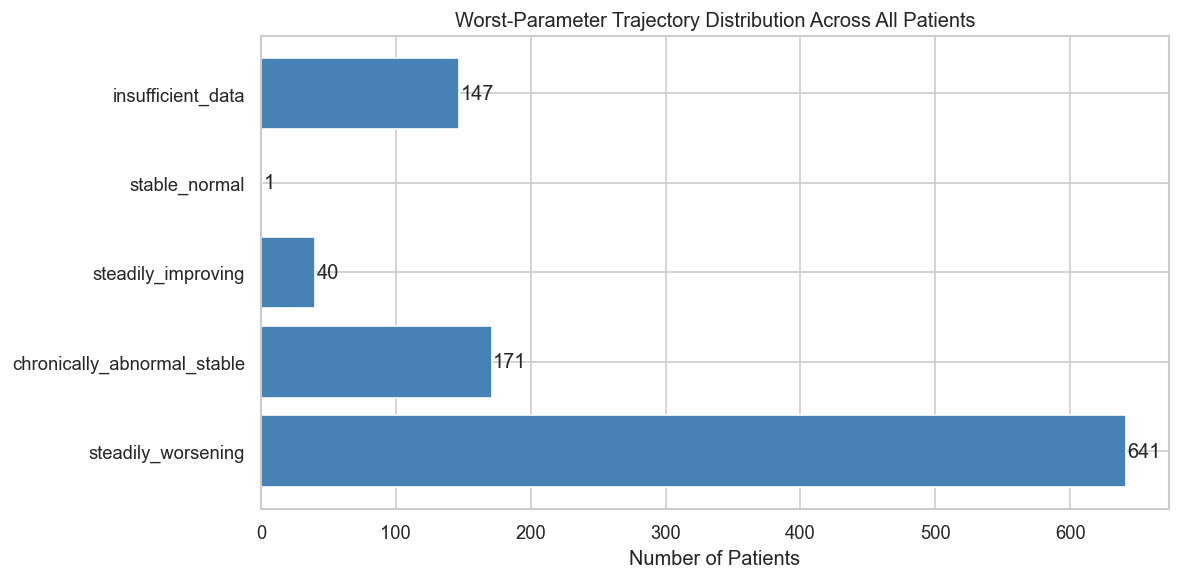

In [27]:

fig, ax = plt.subplots(figsize=(10, 5))
order = [l for l in URGENCY if l in counts.index]
vals = [counts[l] for l in order]
bars = ax.barh(order, vals, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of Patients')
ax.set_title('Worst-Parameter Trajectory Distribution Across All Patients')
for bar, v in zip(bars, vals):
    ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2, str(v), va='center')
plt.tight_layout()
plt.savefig('fig_worst_trajectory.png', bbox_inches='tight')
plt.show()


=== Finding 2: Parameters driving urgent classifications ===
param_name
ldl                270
triglycerides      193
fasting_glucose    160
hdl                147
hba1c              113
sgpt               108
uric_acid           84
sgot                71
creatinine          71
total_protein       38
total_bilirubin     33


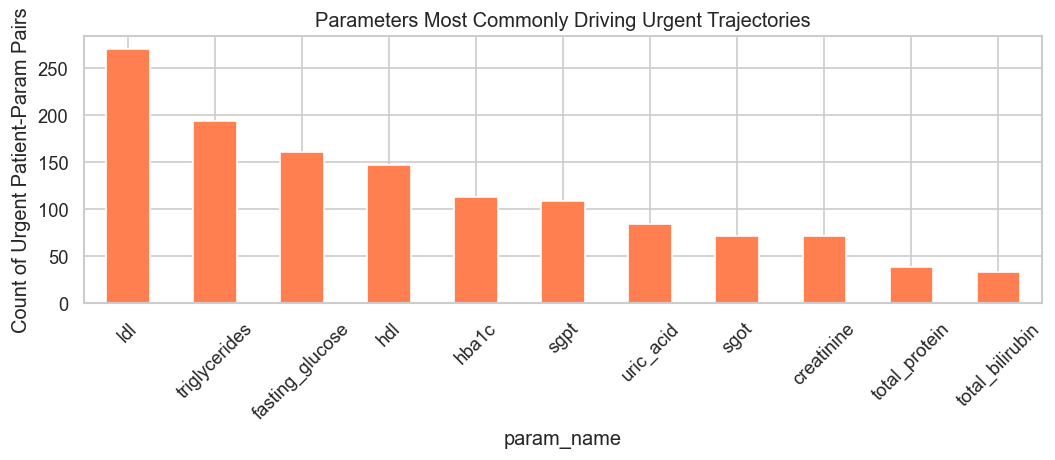

In [28]:

# 5.2 Which params most commonly drive urgent classifications
urgent_labels = {'steadily_worsening','new_problem_emerging','approaching_risk','relapsing'}
urgent_params = traj_df[traj_df['trajectory'].isin(urgent_labels)]['param_name'].value_counts()
print("=== Finding 2: Parameters driving urgent classifications ===")
print(urgent_params.to_string())

fig, ax = plt.subplots(figsize=(9,4))
urgent_params.plot(kind='bar', color='coral', edgecolor='white', ax=ax)
ax.set_title('Parameters Most Commonly Driving Urgent Trajectories')
ax.set_ylabel('Count of Urgent Patient-Param Pairs')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('fig_urgent_params.png', bbox_inches='tight')
plt.show()


In [30]:

# 5.3 Top 3+ parameter pairs with strongest co-occurrence
print("=== Finding 3: Top parameter co-occurrence pairs ===")
print(co_occurrence.head(8).to_string(index=False))


=== Finding 3: Top parameter co-occurrence pairs ===
        param_a       param_b  co_occurrence_count                        typically_first
            ldl triglycerides                  843             ldl becomes abnormal first
            hdl           ldl                  819             hdl becomes abnormal first
            hdl triglycerides                  655             hdl becomes abnormal first
            ldl          sgpt                  530             ldl becomes abnormal first
fasting_glucose           hdl                  517 fasting_glucose becomes abnormal first
          hba1c           ldl                  484           hba1c becomes abnormal first
fasting_glucose           ldl                  471 fasting_glucose becomes abnormal first
fasting_glucose triglycerides                  450 fasting_glucose becomes abnormal first


In [32]:

# 5.4 Top 3+ pairs with consistent temporal ordering
# Build temporal ordering summary table

temp_order = co_occurrence[
    [
        'param_a',
        'param_b',
        'co_occurrence_count',
        'typically_first'
    ]
].copy()

# Remove insufficient data rows
temp_order = temp_order[
    temp_order['typically_first'] != 'insufficient data'
]

# Optional: sort by co-occurrence strength
temp_order = temp_order.sort_values(
    'co_occurrence_count',
    ascending=False
)
print("=== Finding 4: Top temporal orderings (one param becomes abnormal before the other) ===")
print(temp_order.head(10).to_string(index=False))


=== Finding 4: Top temporal orderings (one param becomes abnormal before the other) ===
        param_a       param_b  co_occurrence_count                        typically_first
            ldl triglycerides                  843             ldl becomes abnormal first
            hdl           ldl                  819             hdl becomes abnormal first
            hdl triglycerides                  655             hdl becomes abnormal first
            ldl          sgpt                  530             ldl becomes abnormal first
fasting_glucose           hdl                  517 fasting_glucose becomes abnormal first
          hba1c           ldl                  484           hba1c becomes abnormal first
fasting_glucose           ldl                  471 fasting_glucose becomes abnormal first
fasting_glucose triglycerides                  450 fasting_glucose becomes abnormal first
            hdl          sgpt                  448             hdl becomes abnormal first
fasting_gluc